# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [1]:
import sys
print(sys.executable)

/mnt/e/EmotionDetection-from-voice/venv/bin/python


In [2]:
import matplotlib.pyplot as plt
import librosa.display

print("ALL GOOD ✅")

ALL GOOD ✅


In [3]:
import glob
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

# Dataset Selection

In [ ]:
import glob
import os

data_directory = "/media/anshu/New Volume/Dataset"

wav_files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)
mp4_files = glob.glob(os.path.join(data_directory, "**/*.mp4"), recursive=True)

files = wav_files + mp4_files

print("WAV:", len(wav_files), "MP4:", len(mp4_files))

WAV: 2452 MP4: 4904


In [5]:
from moviepy import VideoFileClip

def convert_mp4_to_wav(mp4_file, output_dir):
    
    base = os.path.basename(mp4_file).replace(".mp4", ".wav")
    output_path = os.path.join(output_dir, base)

    if not os.path.exists(output_path):
        try:
            video = VideoFileClip(mp4_file)
            audio = video.audio
            audio.write_audiofile(output_path)   # ✅ FIXED
            video.close()                        # ✅ important
        except Exception as e:
            print("Error:", mp4_file, e)
            return None

    return output_path

In [6]:
import os
import platform

data_directory = "/mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset"


print("Using dataset path:", data_directory)

if not os.path.exists(data_directory):
    raise FileNotFoundError(f"""
Dataset not found!

Expected path:
{data_directory}

Please update the path in Dataset Selection section.
""")

Using dataset path: /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset


In [7]:
emotion_map_number = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

## 1.1 Dataset Emotion Distribution

WAV: 2452 MP4: 4904
MoviePy - Writing audio in /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset/processed_audio/01-01-01-01-01-01-01.wav


MoviePy - Done.


MoviePy - Writing audio in /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset/processed_audio/01-01-01-01-01-02-01.wav


MoviePy - Done.


MoviePy - Writing audio in /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset/processed_audio/01-01-01-01-02-01-01.wav


...

MoviePy - Done.


MoviePy - Writing audio in /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset/processed_audio/02-02-06-02-02-01-24.wav


MoviePy - Done.


MoviePy - Writing audio in /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset/processed_audio/02-02-06-02-02-02-24.wav


MoviePy - Done.


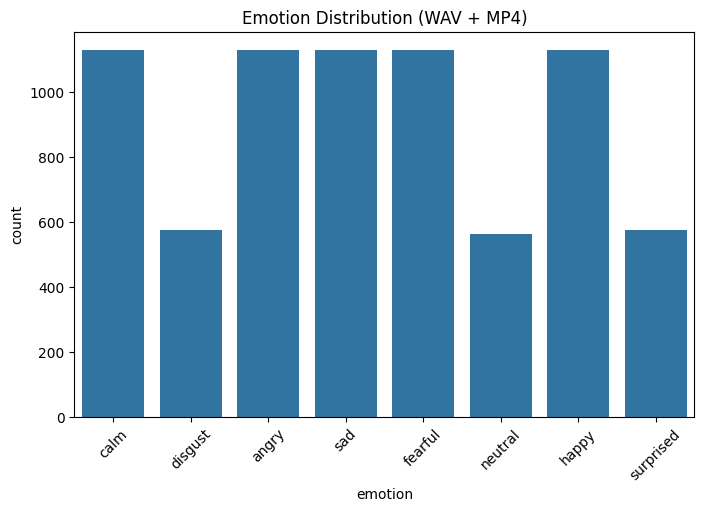

In [8]:
import glob
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from moviepy import VideoFileClip

# ---------- STEP 1: Load both wav + mp4 ----------
wav_files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)
mp4_files = glob.glob(os.path.join(data_directory, "**/*.mp4"), recursive=True)

print("WAV:", len(wav_files), "MP4:", len(mp4_files))

# ---------- STEP 2: Convert MP4 → WAV ----------
audio_output_dir = os.path.join(data_directory, "processed_audio")
os.makedirs(audio_output_dir, exist_ok=True)

processed_files = []


# ---------- STEP 3: Prepare unified file list ----------
for file in wav_files:
    processed_files.append(file)

for file in mp4_files:
    wav_path = convert_mp4_to_wav(file, audio_output_dir)
    if wav_path:
        processed_files.append(wav_path)

# Remove duplicates
processed_files = list(set(processed_files))

# ---------- STEP 4: Extract emotions ----------
emotion_list = []

for file in processed_files:
    file_name = os.path.basename(file)

    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]

    if emotion_code not in emotion_map_number:
        continue

    emotion = emotion_map_number[emotion_code]
    emotion_list.append(emotion)

# ---------- STEP 5: Plot ----------
df = pd.DataFrame(emotion_list, columns=["emotion"])

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution (WAV + MP4)")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
from moviepy import VideoFileClip

def visualize_features(file_path):

    # ---------- HANDLE MP4 ----------
    if file_path.endswith(".mp4"):
        try:
            video = VideoFileClip(file_path)
            audio = video.audio.to_soundarray(fps=22050)
            data = np.mean(audio, axis=1)  # convert to mono
            sr = 22050
            video.close()
        except:
            
            
            
            
            
            
            
            
            
            
            
            
            print("Error reading:", file_path)
            return
    else:
        # ---------- LOAD WAV ----------
        try:
            data, sr = librosa.load(file_path, sr=22050)
        except:
            print("Error reading:", file_path)
            return

    # ---------- EXTRACT EMOTION ----------
    file_name = os.path.basename(file_path)
    try:
        parts = file_name.split("-")
        emotion_code = parts[2]
        emotion = emotion_map_number.get(emotion_code, "unknown")
    except:
        emotion = "unknown"

    # ---------- FEATURE EXTRACTION ----------
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=data, sr=sr)
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=data, sr=sr))
    contrast = librosa.feature.spectral_contrast(y=data, sr=sr)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr)
    zcr = librosa.feature.zero_crossing_rate(data)
    rms = librosa.feature.rms(y=data)

    # ---------- PLOT ----------
    plt.figure(figsize=(15, 20))
    plt.suptitle(f"Emotion: {emotion}", fontsize=16)

    # Waveform
    plt.subplot(8,1,1)
    librosa.display.waveshow(data, sr=sr)
    plt.title("Waveform")

    # MFCC
    plt.subplot(8,1,2)
    librosa.display.specshow(mfcc, x_axis='time')
    plt.colorbar()
    plt.title("MFCC (Timbre)")

    # Chroma
    plt.subplot(8,1,3)
    librosa.display.specshow(chroma, x_axis='time', y_axis='chroma')
    plt.colorbar()
    plt.title("Chroma (Pitch)")

    # Mel
    plt.subplot(8,1,4)
    librosa.display.specshow(mel, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar()
    plt.title("Mel Spectrogram (Frequency)")

    # Contrast
    plt.subplot(8,1,5)
    librosa.display.specshow(contrast, x_axis='time')
    plt.colorbar()
    plt.title("Spectral Contrast")

    # Tonnetz
    plt.subplot(8,1,6)
    librosa.display.specshow(tonnetz, x_axis='time')
    plt.colorbar()
    plt.title("Tonnetz")

    # ZCR
    plt.subplot(8,1,7)
    plt.plot(zcr[0])
    plt.title("ZCR")

    # RMS
    plt.subplot(8,1,8)
    plt.plot(rms[0])
    plt.title("RMS Energy")

    plt.tight_layout()
    plt.show()

File: /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset/Actor_15/03-02-04-02-02-02-15.wav


/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: not enough values to unpack (expected at least 1, got 0)

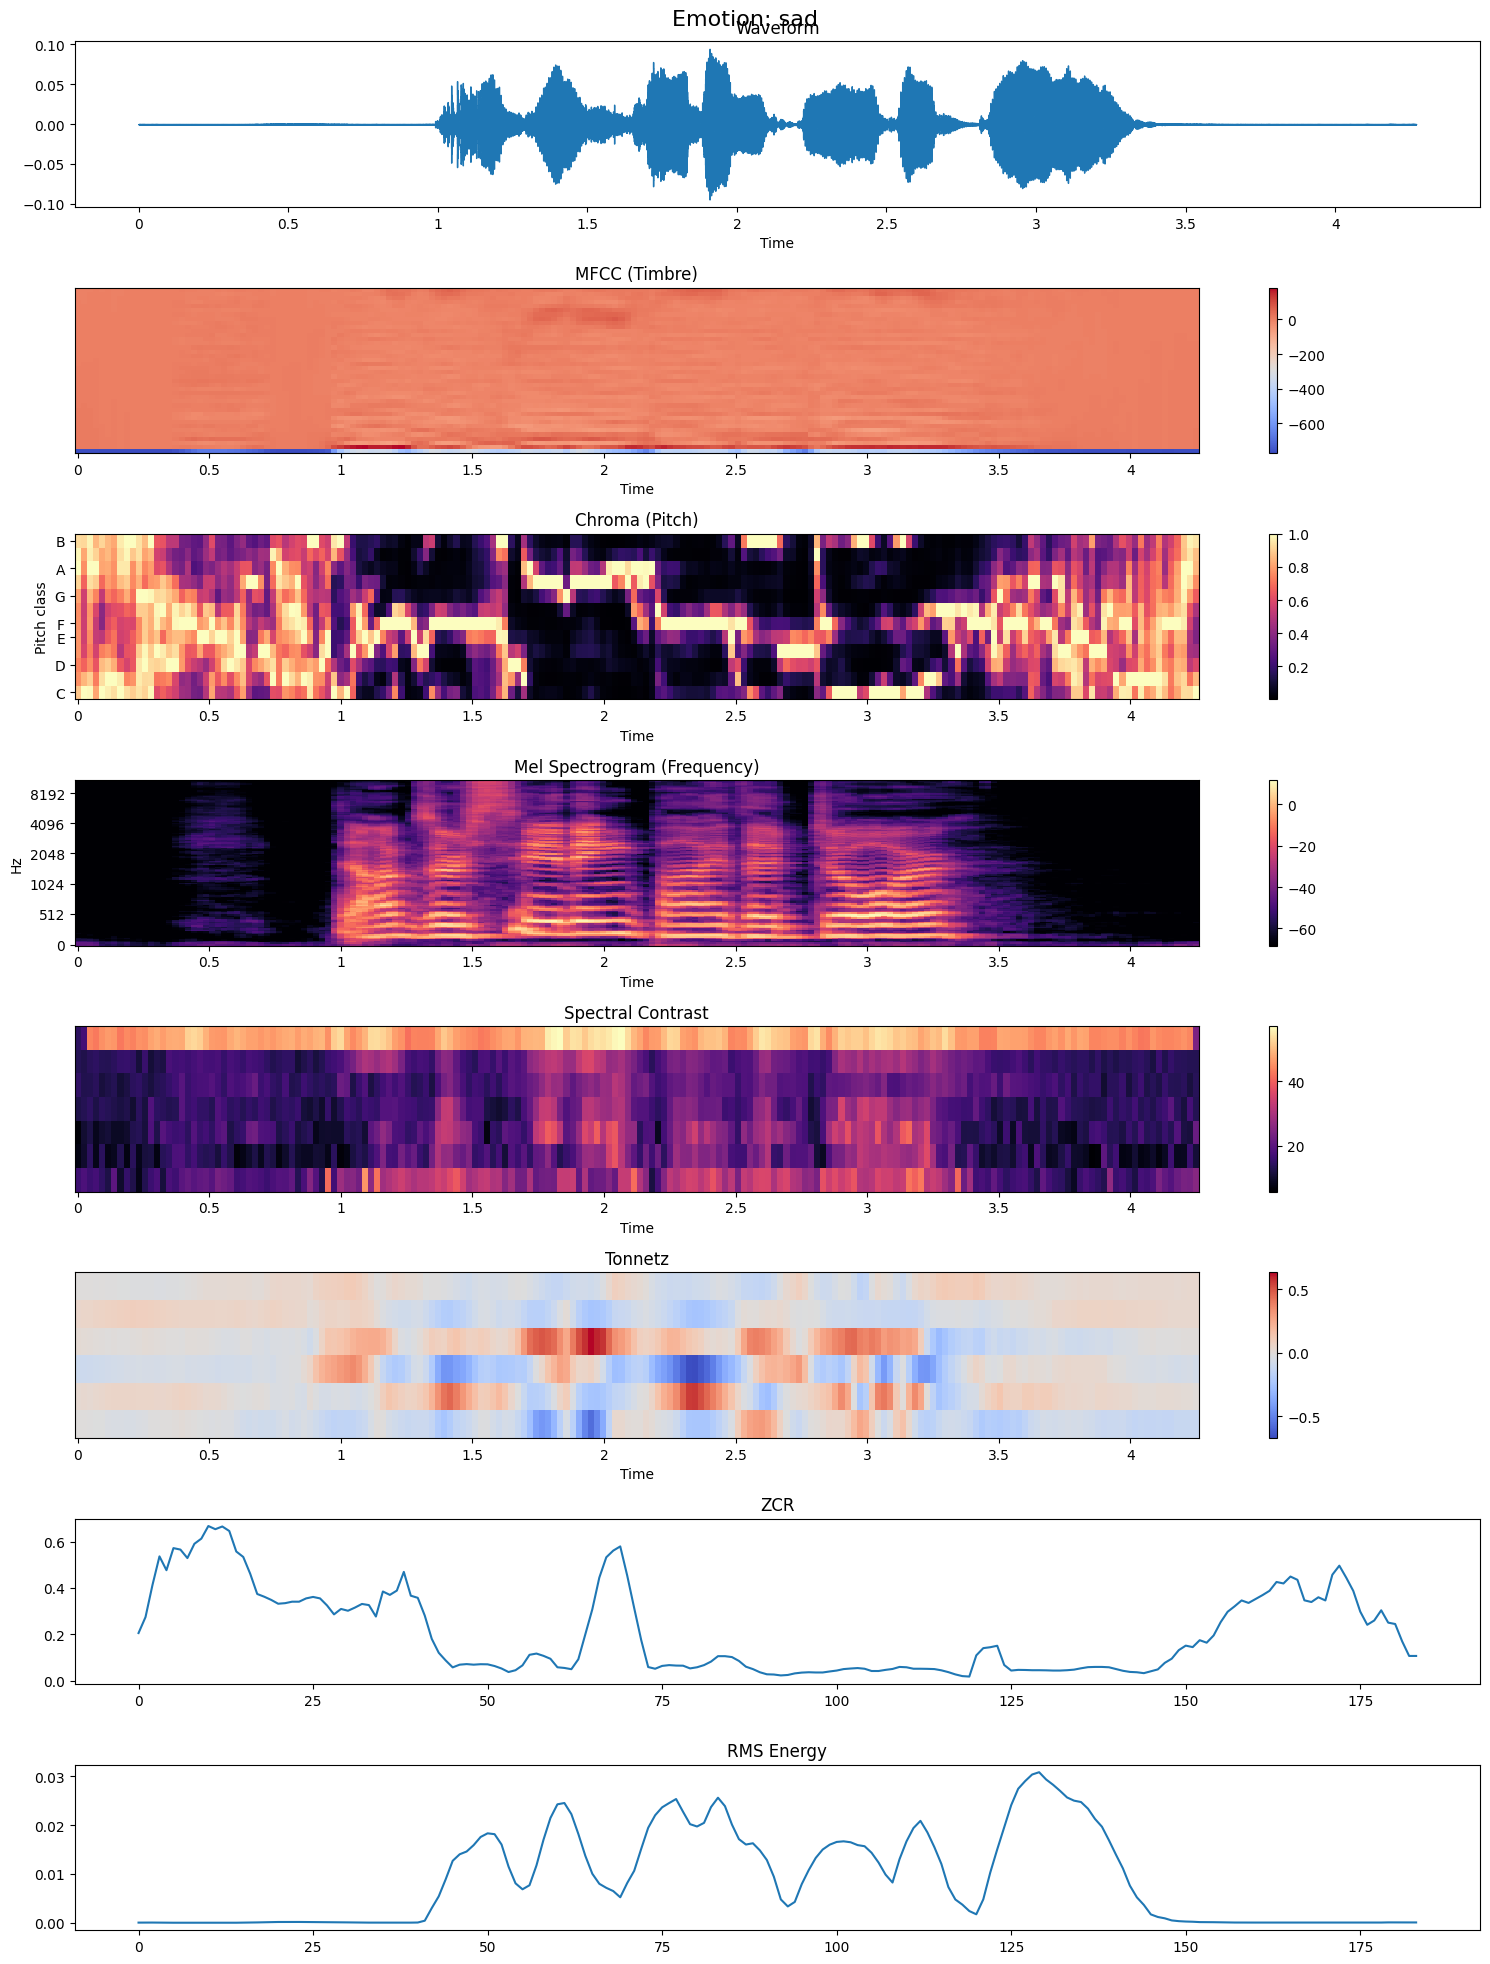

File: /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset/processed_audio/02-02-02-01-02-02-24.wav


/mnt/e/EmotionDetection-from-voice/venv/lib/python3.12/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


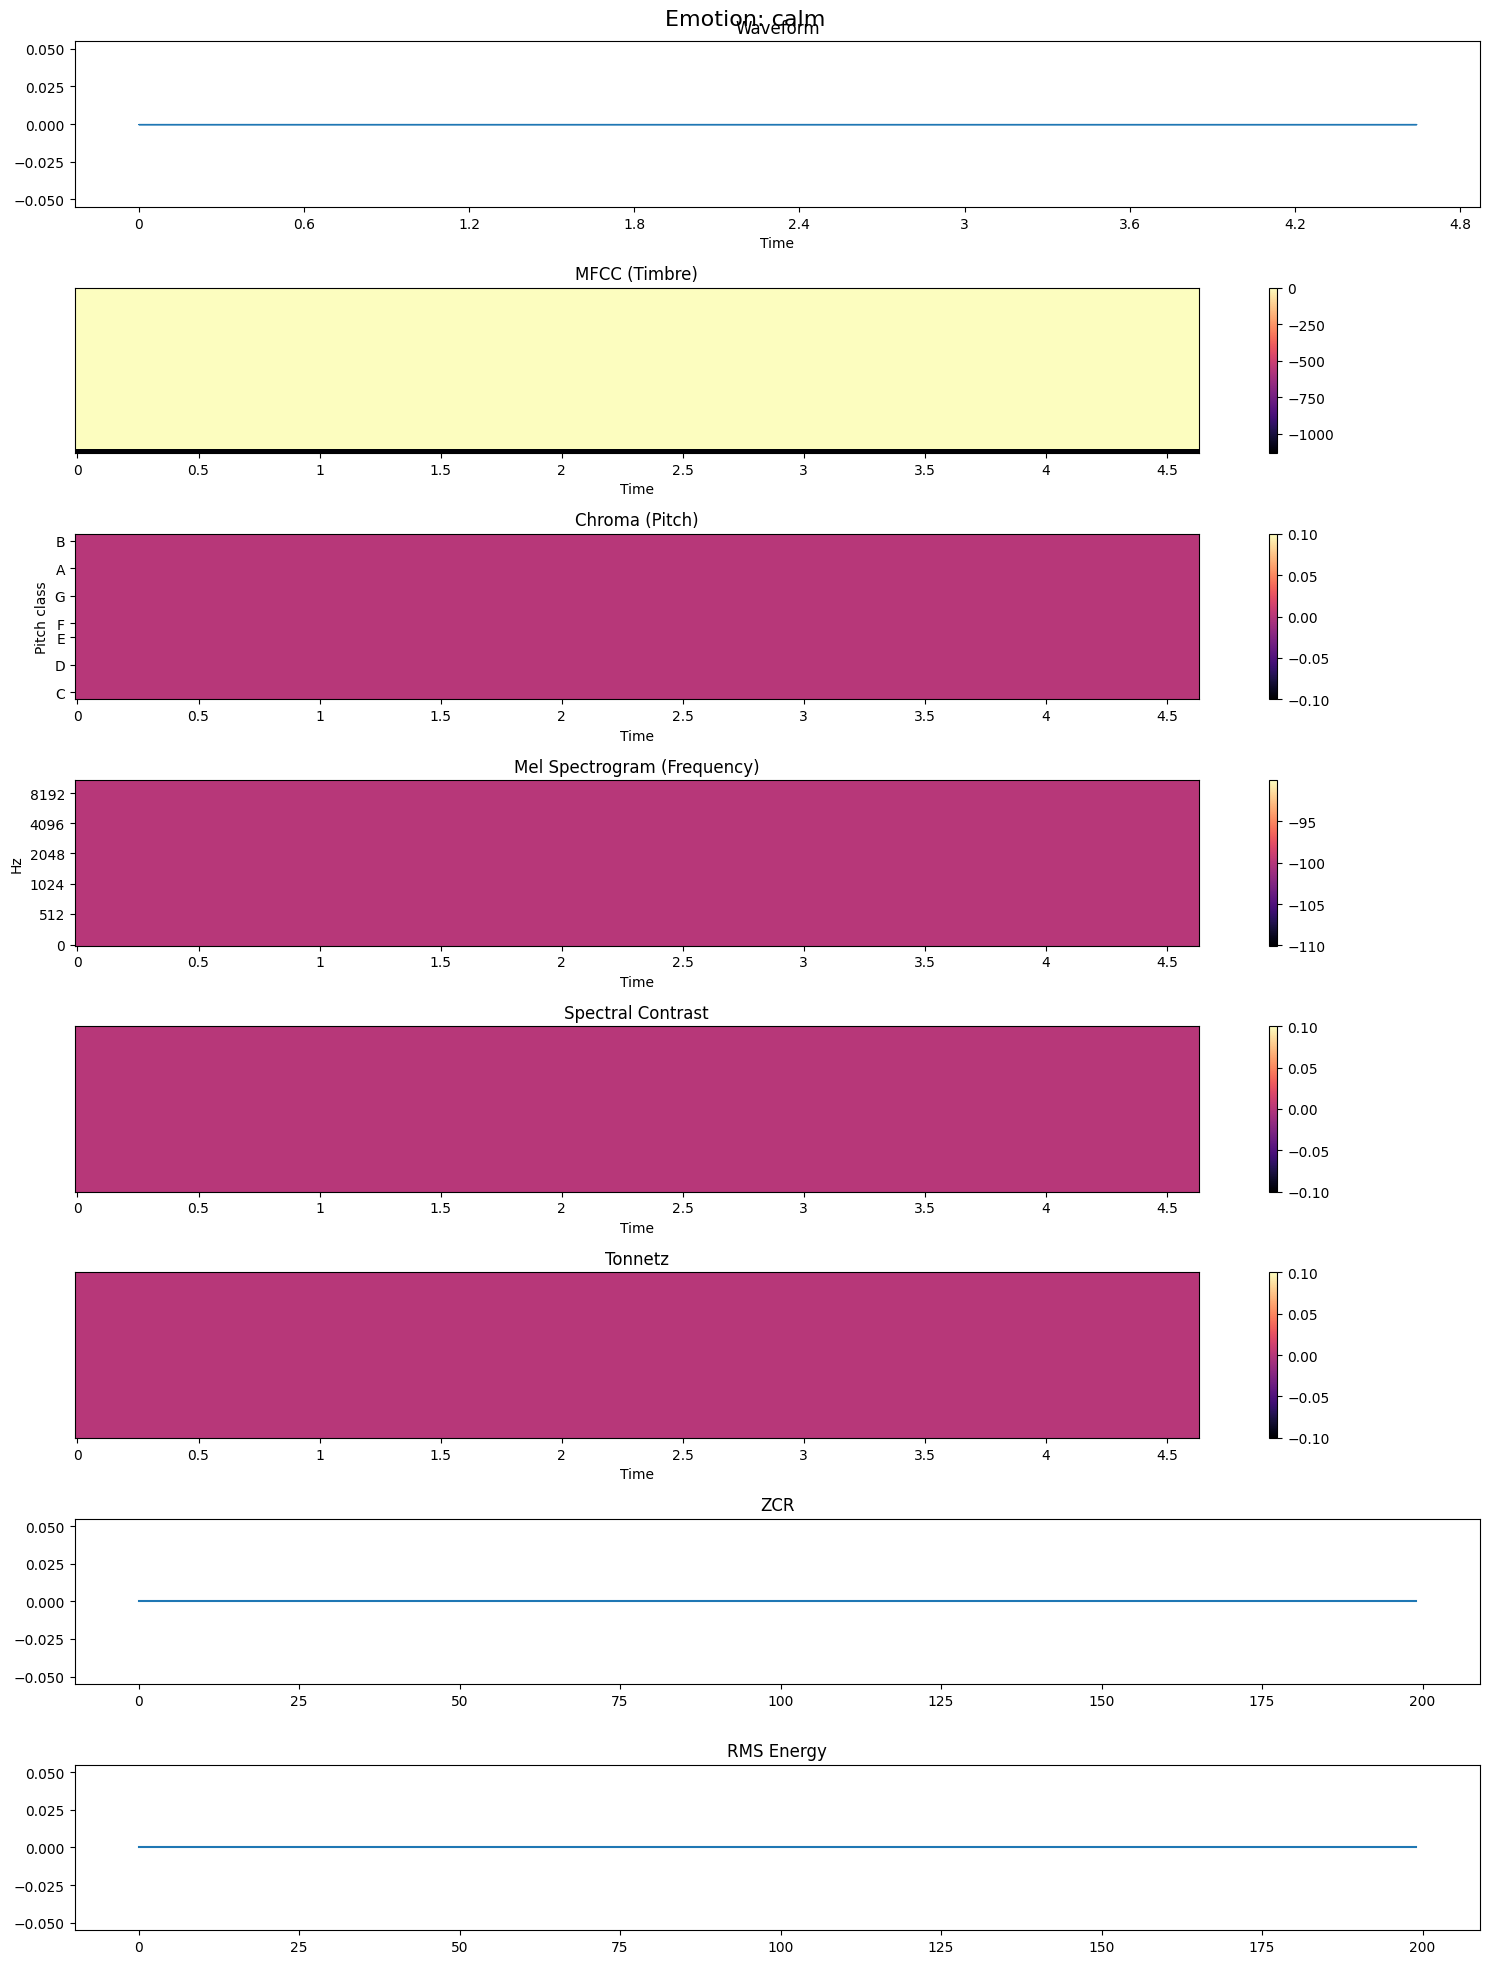

File: /mnt/e/EmotionDetection-from-voice/Ravdees-Training/ravdess/Dataset/processed_audio/01-02-05-02-02-01-14.wav


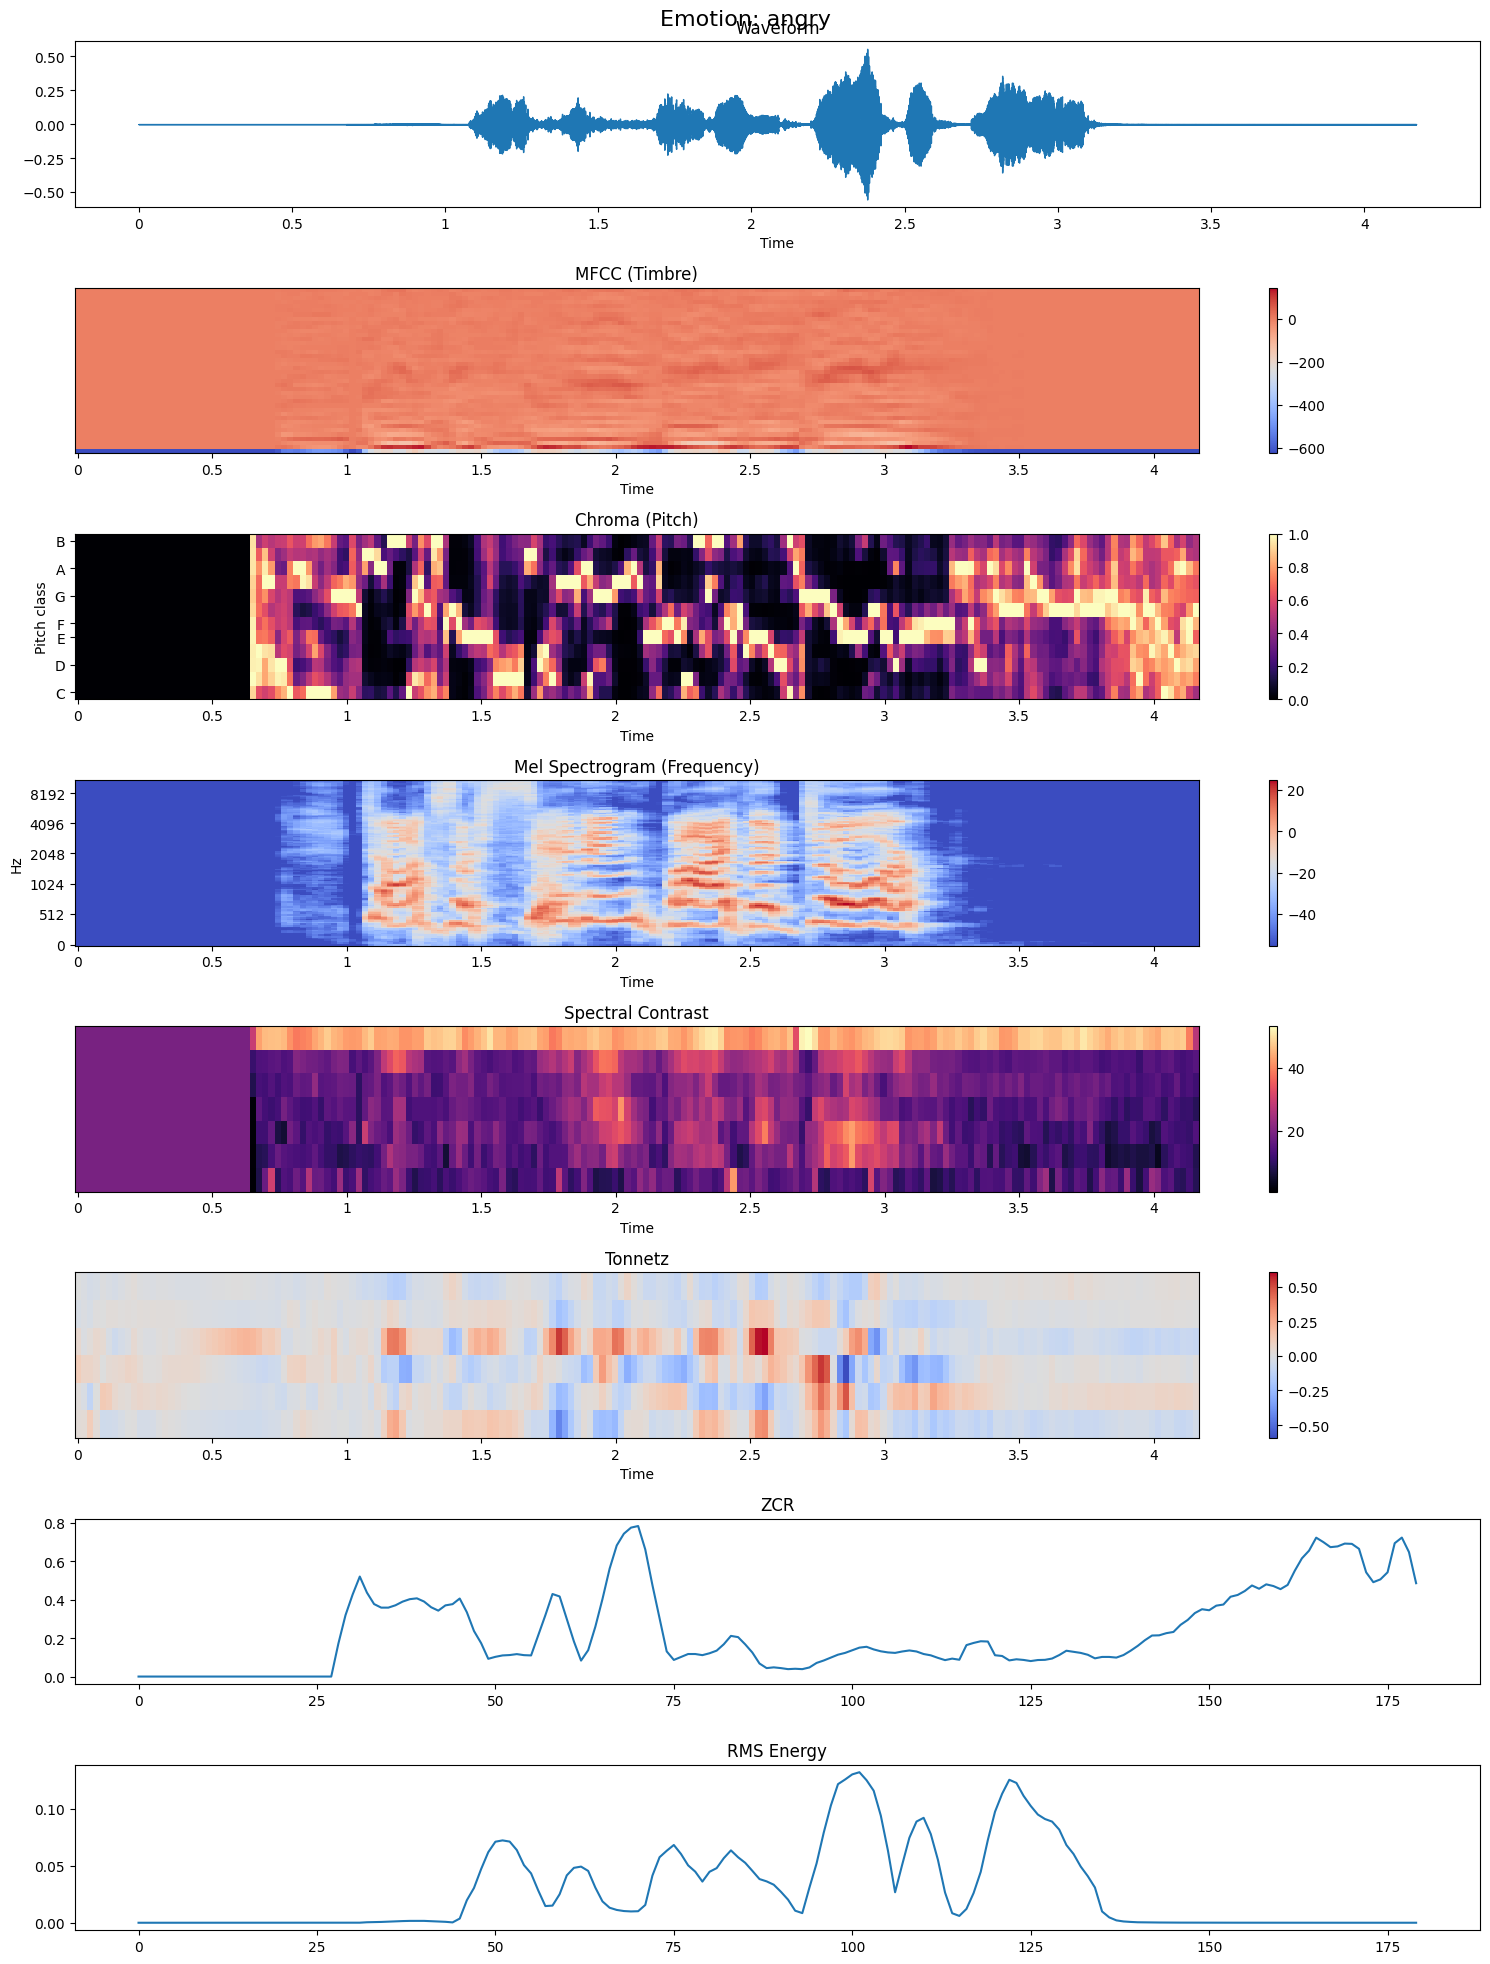

In [10]:
import random

for f in random.sample(processed_files, 3):
    print("File:", f)
    visualize_features(f)

# 1.2 Waveform Visualization

# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [ ]:
emotion_map = {
'angry':0,
'calm':1,
'disgust':2,
'fearful':3,
'happy':4,
'neutral':5,
'sad':6,
'surprised':7
}

def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(8)

    if secondary:
        label[emotion_map[primary]] = w1
        label[emotion_map[secondary]] = w2
    else:
        label[emotion_map[primary]] = 1.0

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

In [ ]:
def mix_multiple_audio(files, weights):

    signals = []
    sr = None

    for file in files:
        data, sr = librosa.load(file)
        signals.append(data)

    # Match lengths
    min_len = min([len(s) for s in signals])
    signals = [s[:min_len] for s in signals]

    # Weighted sum
    mixed = np.zeros(min_len)

    for s, w in zip(signals, weights):
        mixed += w * s

    # Normalize
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-6)

    return mixed, sr

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [ ]:
np.random.seed(42)

In [ ]:
# Initialize
X, y = [], []

emotion_list = list(emotion_map.keys())

# Debug: track label distribution
label_check = []

for file in processed_files:

    # -------- ORIGINAL SAMPLE --------
    data, sr = librosa.load(file)
    feature = extract_feature(data, sr)

    file_name = os.path.basename(file)

    # Extract emotion safely
    parts = file_name.split("-")
    emotion_code = parts[2]

    if len(parts) < 3:
        print("Skipping invalid filename:", file_name)
        continue

    # Strict mapping (NO silent fallback)
    if emotion_code not in emotion_map_number:
        print("Unknown emotion code:", emotion_code, "in file:", file_name)
        continue

    primary_emotion = emotion_map_number[emotion_code]

    X.append(feature)
    y.append(create_soft_label(primary_emotion))

    label_check.append(primary_emotion)

    # -------- MIXED SAMPLE --------
    if np.random.rand() < 0.2:   # 20% augmentation

        n_mix = 2

        selected_emotions = np.random.choice(emotion_list, n_mix, replace=False)

        selected_files = []

        for e in selected_emotions:
            if e in emotion_files and len(emotion_files[e]) > 0:
                selected_files.append(np.random.choice(emotion_files[e]))

        # Skip if files missing
        if len(selected_files) != len(selected_emotions):
            continue

        # Generate weights
        weights = np.random.dirichlet(np.ones(n_mix))

        # Mix audio
        mixed_audio, sr = mix_multiple_audio(selected_files, weights)

        # Extract features
        feature = extract_feature(mixed_audio, sr)
        X.append(feature)

        # Create soft label
        label = np.zeros(len(emotion_map))
        for emo, w in zip(selected_emotions, weights):
            label[emotion_map[emo]] = w

        y.append(label)

# Convert to numpy
X = np.array(X)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_flat = X.reshape(X.shape[0], -1)
X_flat = scaler.fit_transform(X_flat)

X = X_flat.reshape(X.shape)

# add channel
X = np.expand_dims(X, axis=-1)

y = np.array(y)

# Debug: label distribution
import collections
print("\nLabel Distribution:")
print(collections.Counter(label_check))

print("\nDataset size:", X.shape)

# Normalize Features

In [ ]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Saving the Features

In [ ]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("emotion_map.pkl", "wb") as f:
    pickle.dump(emotion_map, f)

In [ ]:
emotion_files = {}

for file in processed_files:
    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]

    if emotion_code not in emotion_map_number:
        continue

    emotion = emotion_map_number[emotion_code]

    if emotion not in emotion_files:
        emotion_files[emotion] = []

    emotion_files[emotion].append(file)

# Data Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)
print(np.bincount(np.argmax(y, axis=1)))

# Reshaping the Data

In [ ]:
# X_train = np.expand_dims(X_train, axis=2)
# X_test = np.expand_dims(X_test, axis=2)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5
)

# Model checkpoint

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

labels = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

In [ ]:
import tensorflow as tf

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
print("Available GPUs:", gpus)

# Enable memory growth (prevents crashes)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# OPTIONAL: force GPU (strong guarantee)
with tf.device('/GPU:0'):
    print("Using GPU explicitly")

In [ ]:
with tf.device('/GPU:0'):

    model = Sequential()

    model.add(Conv2D(32, (3,3), activation='relu',
                     input_shape=X.shape[1:]))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.2))

    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.3))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.4))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(8, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='kullback_leibler_divergence',   # 🔥 FIXED (soft labels)
        metrics=['accuracy']
    )

    model.summary()

    history = model.fit(
        X_train,
        y_train,
        epochs=60,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr, checkpoint],
        class_weight=class_weights
    )

# Model Save

In [ ]:
model.save("final_model_cnn.keras")

# Evaluation Matrics

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(emotion_map.keys())))

# confusion matrix visual

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)

In [ ]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model_cnn.keras")

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

### Save new audio:

In [ ]:
emotions_sample = np.random.choice(list(emotion_map.keys()), 3, replace=False)
files = [np.random.choice(emotion_files[e]) for e in emotions_sample]
weights = np.random.dirichlet(np.ones(len(files)))

mixed, sr = mix_multiple_audio(files, weights)

sf.write("mixed_audio.wav", mixed, sr)

# Real-Time Emotion Detection

Record audio:

In [ ]:
import sounddevice as sd

def record_audio(duration=3, sr=22050):

    print("Speak now")

    audio = sd.rec(int(duration*sr),
                   samplerate=sr,
                   channels=1)

    sd.wait()

    return audio.flatten()

# Predict emotion:

In [ ]:
import pickle
from tensorflow.keras.models import load_model

loaded_model = loaded_model = load_model("final_model_cnn.keras")

# with open("scaler.pkl", "rb") as f:
#     scaler = pickle.load(f)

with open("emotion_map.pkl", "rb") as f:
    emotion_map = pickle.load(f)

audio = record_audio()

feature = extract_feature(audio, 22050)

feature = (feature - np.mean(feature)) / (np.std(feature) + 1e-6)

feature = scaler.transform(feature.reshape(1, -1))
feature = feature.reshape(1, X.shape[1], X.shape[2], 1)


prediction = loaded_model.predict(feature)

inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction)]

print("Emotion:", emotion)